## Dataset

- Name: California Housing dataset
- Task: Regression
- Source: scikit-learn

The dataset is automatically downloaded using:

`fetch_california_housing()`

Reference:
https://scikit-learn.org/stable/datasets/real_world.html

<h1> Linear Regression </h1>

#### In this notebook, we first build the model manually from scratch and then compare it with the library-based model.

Linear Regression is one of the most fundamental machine learning algorithms.

Objective:

To find the relationship between:

Input variables (features)</br>
Output variable (target)

...in such a way that we can predict the value of the target.

Let's assume we have a feature:

$$ x $$

### **The linear model** is:

$$ \hat y = wx+b $$

where:

$w$: weight or slope of the line
$b$: bias or y-intercept

W represents the model's weights; essentially, the model learns the importance of each feature.

However, in the case of multiple features:

$$ X= [x_1,x_2,...,x_n] $$

The model becomes:

$$ \hat y = w_1x_1+w_2x_2+...+w_nx_n+b $$

Or in matrix form:

$$ \hat y=XW+b $$


### **The goal of model training**:

We need  to find the optimal:

$$ W,b $$

such that the predictions:

$$ \hat y $$

come as close as possible to the actual values:

$$ y $$


### **Cost Function**

We typically use:

Mean Squared Error

$$ MSE= \frac1n \sum_{i=1}^{n} (y_i-\hat y_i)^2 $$

Why the square?

Because:

It penalizes large errors more heavily
It is differentiable

Gradient

For Weights:

$$ \frac{\partial J}{\partial W} = -\frac{2}{n} X^T(y-\hat y) $$

For Bias:

$$ \frac{\partial J}{\partial b} = -\frac{2}{n} \sum(y-\hat y) $$
Update Rule

Weight:

$$ W=W-\alpha dW $$

Bias:

$$ b=b-\alpha db $$


### **Evaluation**

For Regression:

MAE:</br>
$$ \frac1n\sum |y-\hat y| $$

MSE:</br>
$$ \frac1n\sum(y-\hat y)^2 $$

RMSE:</br>
$$ \sqrt{MSE} $$

R²: </br>
$$ 1-\frac{SS_{res}}{SS_{tot}} $$


### **Training Methods**

There are two well-known methods:

1. Method 1: Normal Equation

Direct solution:

$$ W=(X^TX)^{-1}X^Ty $$

Advantage:

No iteration required

Disadvantage:

Slow when there are many features

2. Method 2: Gradient Descent

A fundamental machine learning method.

Concept:

Start with random weights:

W = random

Then:

Make a prediction</br>
Calculate the error</br>
Find the gradient</br>
Update the weights

Update formula:

$$ W=W-\alpha \frac{\partial J}{\partial W} $$

Where:

$$ \alpha $$

is the learning rate.

In [31]:
import sys
import os

sys.path.append(
    os.path.abspath("../..")
)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from src.linear_regression import LinearRegressionGD

In [33]:
from model_evaluation.src.regression_metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

<h3> Step 1: Loading The Dataset </h3>

In [34]:
data = fetch_california_housing(
    as_frame=True
)

df = data.frame

In [35]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<h3> Step 2: Exploratory Data Analysis </h3>

In [36]:
df.shape

(20640, 9)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [38]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [39]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

An important point regarding Linear Regression:

Is Linear Regression sensitive to feature scaling?

Mathematically speaking:

Linear Regression itself, when solved directly, does not strictly require scaling.

However, we intend to:

implement Gradient Descent.

In Gradient Descent:

If feature scales differ, the error surface becomes distorted, making training slow or unstable. Therefore, scaling is necessary.

<h3> Step 3: Analyzing the Relationship Between Features and the Target </h3>

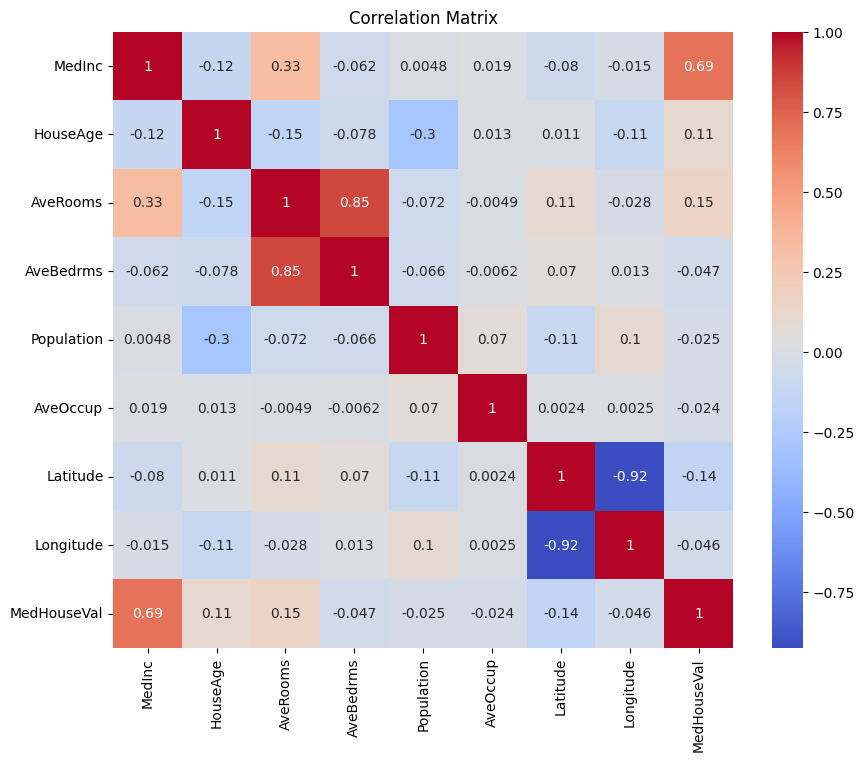

In [40]:
corr = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [41]:
corr[
    "MedHouseVal"
].sort_values(
    ascending=False
)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

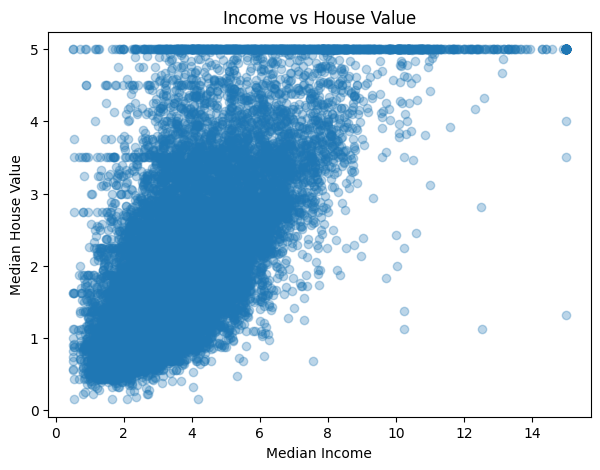

In [42]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel(
    "Median Income"
)

plt.ylabel(
    "Median House Value"
)

plt.title(
    "Income vs House Value"
)

plt.show()

We observe:

At lower income levels, prices are more dispersed.</br>
As income increases, the value of MedHouseVal rises.</br>
However, the relationship is not strictly linear.

That is:

$$ MedHouseVal \neq a \times MedInc+b $$

It is not perfectly linear, yet a positive trend exists.

### EDA Findings

- The dataset contains no missing values and all features are numerical.
- Median income (MedInc) has the strongest linear relationship with house value.
- Some features such as AveRooms and AveBedrms show high correlation with each other, indicating possible multicollinearity.
- The target variable is clipped around value 5, which may limit predictions for expensive houses.
- Feature scaling will be applied because Gradient Descent optimization is sensitive to feature magnitude.

<h3> Step 4: Train/Test Split </h3>

In [43]:
X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


An important point regarding Linear Regression:

We have two types of parameters:

Model parameters:

Which must be learned:

$$ W, b $$

Preprocessing parameters:

Such as:

Mean

Standard Deviation

(used in scaling)

These, too, must be learned solely from the training data.

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [45]:
print(
    X_train_scaled.mean(axis=0)
)

print(
    X_train_scaled.std(axis=0)
)

[-6.51933288e-17 -9.25185854e-18 -1.98108110e-16 -1.70729064e-16
 -2.15159501e-19  4.93656580e-17  6.40099515e-17  1.75333477e-15]
[1. 1. 1. 1. 1. 1. 1. 1.]


<h3> Step 5: Model Implementation (Manually) </h3>

X_train , y_train

        ↓

Initialize weights

        ↓

Prediction

        ↓

Calculate Error

        ↓

Calculate Gradient

        ↓

Update Weights

        ↓

Repeat

Function:

fit()

Functionality: Learn the model parameters.

Function:

predict()

Functionality: Use the learned parameters to predict new data.

Step 5.1: Model construction:

In [46]:
model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)

Step 5.2: Train

In [47]:
model.fit(
    X_train_scaled,
    y_train.values
)

In [48]:
model.weights

array([ 0.8580605 ,  0.1501549 , -0.25253771,  0.28100715,  0.00710958,
       -0.04344213, -0.68321834, -0.65415242])

In [49]:
model.bias

2.071946933891859

Step 5.3: Prediction

In [50]:
y_pred = model.predict(
    X_test_scaled
)

In [51]:
y_pred[:10]

array([0.79795208, 1.70856504, 2.63039776, 2.79875658, 2.46876694,
       2.05398258, 2.66444346, 2.17279691, 2.57357574, 3.99158605])

Step 5.4: Analyzing the Loss Curve

The loss stored within the training loop corresponds to the training phase.

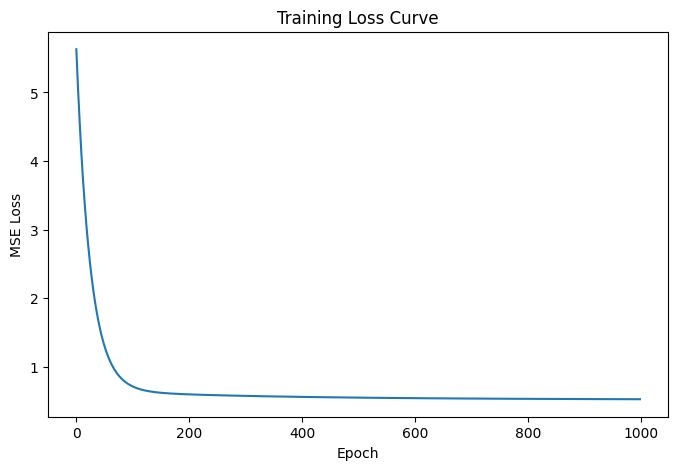

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    model.loss_history
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Training Loss Curve"
)

plt.show()

<h3> Step 6: Model Evaluation </h3>

Metric 1 — MAE</br>
Metric 2 — MSE </br>
Metric 3 — RMSE </br>
Metric 4 — R² Score

In [53]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = root_mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

In [54]:
print(
    f"MAE: {mae:.4f}"
)

print(
    f"MSE: {mse:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R2: {r2:.4f}"
)

MAE: 0.5352
MSE: 0.5546
RMSE: 0.7447
R2: 0.5768


#### Model Evaluation Results

After training the Linear Regression model using Gradient Descent, the model performance was evaluated on the test dataset using four common regression metrics: MAE, MSE, RMSE, and \(R^2\) Score.

Results:</br>
MAE  : 0.5352</br>
MSE  : 0.5546</br>
RMSE : 0.7447</br>
R²   : 0.5768

Interpretation:
MAE (0.5352) indicates that the model's predictions are, on average, approximately 0.54 units away from the actual median house value.

MSE (0.5546) measures the squared prediction error and penalizes larger errors more heavily than MAE.

RMSE (0.7447) represents the average prediction error in the same scale as the target variable. Compared with MAE, the larger RMSE value suggests that some predictions have relatively larger errors.

R² Score (0.5768) means that the model explains approximately 57.7% of the variance in the median house value. The remaining variation is caused by factors not captured by the current linear model or by the nonlinear relationships present in the dataset.

Overall, the results show that Linear Regression can capture important linear patterns in the housing dataset, but its performance is limited because housing prices are affected by complex nonlinear relationships and interactions between features.

<h3> Step 7: Compare Our Implementation with Scikit-Learn </h3>

An important point regarding `sklearn`'s `LinearRegression`:

The model we built uses:

Gradient Descent

That is:

$$ W=W-\alpha\nabla J $$

However, `sklearn` typically uses:

Ordinary Least Squares (OLS)

Meaning it finds the optimal solution directly:

$$ W=(X^TX)^{-1}X^Ty $$

(Though in practice, it employs more numerically stable methods like SVD.)

Step 7.1: Model building

In [55]:
sklearn_model = LinearRegression()

Step 7.2: Train

In [56]:
sklearn_model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

Step 7.3: Prediction

In [57]:
sklearn_pred = sklearn_model.predict(
    X_test_scaled
)

Step 7.4: Metrics

In [58]:
sklearn_mae = mean_absolute_error(
    y_test,
    sklearn_pred
)

sklearn_mse = mean_squared_error(
    y_test,
    sklearn_pred
)

sklearn_rmse = np.sqrt(
    sklearn_mse
)

sklearn_r2 = r2_score(
    y_test,
    sklearn_pred
)

In [ ]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Custom Gradient Descent",
            "Scikit-Learn Linear Regression"
        ],

        "MAE": [
            mae,
            sklearn_mae
        ],

        "RMSE": [
            rmse,
            sklearn_rmse
        ],

        "R2": [
            r2,
            sklearn_r2
        ]
    }
)

comparison

,Model,MAE,RMSE,R2
0,Custom Gradient Descent,0.535207,0.744701,0.576789
1,Scikit-Learn Linear Regression,0.533200,0.745581,0.575788


In [60]:
model.weights

array([ 0.8580605 ,  0.1501549 , -0.25253771,  0.28100715,  0.00710958,
       -0.04344213, -0.68321834, -0.65415242])

In [61]:
sklearn_model.coef_

array([ 0.85438303,  0.12254624, -0.29441013,  0.33925949, -0.00230772,
       -0.0408291 , -0.89692888, -0.86984178])

The custom Gradient Descent implementation achieved comparable performance to Scikit-Learn's Linear Regression, validating the correctness of the implemented optimization process.